# DFT+U

LDA and GGA are too happy with fractional occupation of a localised shell, which is why
they make a metal out of an insulating transition-metal oxide. Dudarev's correction adds
a penalty that is zero at every integer occupation and positive in between, so the SCF is
pushed towards filled and empty orbitals.

QE's `lda_plus_u_kind = 0`, read from the `HUBBARD` card, with `U`, `J0`, `alpha` and
`beta` on `atomic`, `ortho-atomic` or `norm-atomic` projectors. Seven cases match Quantum
ESPRESSO to **≤6.7e-9 Ry**, the Hubbard term itself to 4.6e-7 Ry, and `force_hub` — which
is not transcribed, only differentiated through — to 4.8e-6 Ry/bohr.

Dudarev's simplified rotationally-invariant functional, written in terms of the
occupation matrix of each correlated shell:

$$E_U = \sum_{I,\sigma} \frac{U^I - J^I_0}{2}\,
   \mathrm{Tr}\Big[ n^{I\sigma} \big( 1 - n^{I\sigma} \big) \Big],
\qquad
n^{I\sigma}_{mm'} = \sum_{n\mathbf k} f_{n\mathbf k\sigma}
   \langle \psi_{n\mathbf k\sigma} | \varphi^I_{m'}\rangle
   \langle \varphi^I_{m} | \psi_{n\mathbf k\sigma}\rangle$$

It is zero at every integer occupation and positive between, so its potential
$v^{I\sigma} = \partial E_U / \partial n^{I\sigma}$ pushes empty levels up and full
ones down. **Only $E_U$ is written here** and $v$ is `jax.grad` of it, which makes QE's
`v_hubbard` a test rather than a second implementation.

Phase P20.

HUBBARD {atomic}
U Fe1-3d 4.3
U Fe2-3d 4.3



Fe1: 3d   U = 4.30 eV = 0.316044 Ry   (the card is in eV; Ry from here on)
Fe2: 3d   U = 4.30 eV = 0.316044 Ry   (the card is in eV; Ry from here on)


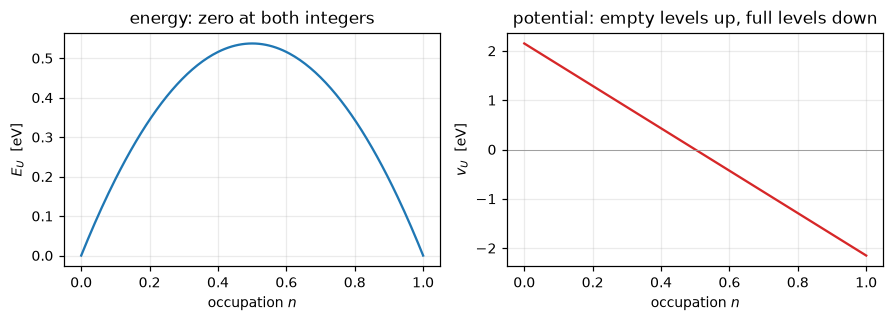

In [1]:
from pathlib import Path

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from pypresso.hubbard.energy import (coefficients_from_setup, hubbard_potential,
                                     qe_hubbard_potential)
from pypresso.hubbard.manifold import build_hubbard_setup
from pypresso import Calculator
from pypresso.io import read_qe_output
from pypresso.io.pwin import parse_pw_input
from pypresso.pseudo.atomic import atomic_wavefunctions
from pypresso.units import RY_TO_EV

PSEUDO, GENERATED = Path("../tests/data/pseudo"), Path("../tests/data/qe")
TESTSUITE = Path("../quantum_espresso/qe-7.5-ReleasePack/qe-7.5/test-suite")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})


def load(text):
    """A calculator carrying the input's own mixing settings.

    These are the cases that need them: a Hubbard SCF is stiff, and
    `mixing_fixed_ns` holds the occupation matrix still for the first few
    iterations. Put on the calculator once, they reach every method.
    """
    pwin = parse_pw_input(text)
    return Calculator.from_text(
        text, PSEUDO, announce=False, conv_thr=1e-10, max_iterations=250,
        mixing_beta=float(pwin.get("electrons", "mixing_beta", 0.7)),
        mixing_fixed_ns=int(pwin.get("electrons", "mixing_fixed_ns", 0)),
    )


u = 4.3 / RY_TO_EV                                   # the FeO benchmark's U, in Ry
n = np.linspace(0.0, 1.0, 201)
fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.0))
axes[0].plot(n, 0.5 * u * (n - n**2) * RY_TO_EV, color="C0")
axes[0].set_ylabel(r"$E_U$  [eV]"); axes[0].set_title("energy: zero at both integers")
axes[1].plot(n, u * (0.5 - n) * RY_TO_EV, color="C3")
axes[1].axhline(0.0, lw=0.6, color="0.6")
axes[1].set_ylabel(r"$v_U$  [eV]")
axes[1].set_title("potential: empty levels up, full levels down")
for ax in axes:
    ax.set_xlabel("occupation $n$"); ax.grid(alpha=0.25)
fig.tight_layout()

feo_input = (TESTSUITE / "pw_lda+U" / "lda+U.in").read_text()
print(feo_input[feo_input.index("HUBBARD"):])
feo = load(feo_input)
system_feo, pseudos_feo = feo.system, feo.pseudos
setup = build_hubbard_setup(system_feo.hubbard, system_feo.structure, pseudos_feo)
for slot, kind in enumerate(setup.types):
    item, name = setup.species[kind], system_feo.structure.species[kind].name
    print("%s: %d%s   U = %.2f eV = %.6f Ry   (the card is in eV; Ry from here on)"
          % (name, item.n, "spdf"[item.l], item.u * RY_TO_EV, item.u))

## Two traps in the word "atomic"

`Hubbard_projectors = 'atomic'` still applies the overlap operator — the projectors are
$S\varphi$, not $\varphi$. And the atomic orbitals are renormalised at read time in the
**generalised** metric (`upf_check_atwfc_norm`), which `ortho-atomic` feels through the
`4s` while `atomic` does not: nickel's `4s` and `3d` on the same atom are not orthogonal
at a single k-point, and $O^{-1/2}$ over **all** `natomwfc` is what fixes that.

In [2]:
nickel = load((GENERATED / "ni-ldau-ortho.in").read_text())
system_ni, pseudos_ni = nickel.system, nickel.pseudos
calc_ni = nickel.calculation
phi = atomic_wavefunctions(pseudos_ni, system_ni.structure, system_ni.cell,
                           calc_ni.basis.smooth, calc_ni.basis.planewaves,
                           system_ni.kpoints)[0]
sphi = calc_ni._overlap(phi, 0)
plain = np.asarray(jnp.conj(phi) @ phi.T)
generalised = np.asarray(jnp.conj(phi) @ sphi.T)

print("nickel: %d atomic orbitals per atom (4s + 3d)" % phi.shape[0])
print("<phi|phi>   diagonal: %s" % np.round(np.diag(plain).real, 4))
print("<phi|S|phi> diagonal: %s" % np.round(np.diag(generalised).real, 4))
print("largest off-diagonal of <phi|S|phi>: %.4f"
      % np.abs(generalised - np.diag(np.diag(generalised))).max())

nickel: 6 atomic orbitals per atom (4s + 3d)
<phi|phi>   diagonal: [9.8981 0.1514 0.218  0.218  0.1514 0.218 ]
<phi|S|phi> diagonal: [8.3061 0.8437 1.0323 1.0323 0.8437 1.0323]
largest off-diagonal of <phi|S|phi>: 0.1857


## The potential is `jax.grad` of the energy

$E_U$ is written down once and $v_{ns}$ is its gradient, so QE's `v_hubbard` becomes a
**test** rather than a second implementation. Below, with `U`, `J0`, `alpha` and `beta`
all switched on, against a random symmetric occupation matrix.

In [3]:
import copy

check = copy.deepcopy(setup)
for item in check.species:
    if item is not None:
        item.u, item.j0, item.alpha, item.beta = 0.30, 0.05, 0.02, 0.03
coefficients = coefficients_from_setup(check)

rng = np.random.default_rng(0)
block = rng.normal(size=(2, check.nslot, check.ldmx, check.ldmx))
ns = jnp.asarray(0.5 * (block + block.transpose(0, 1, 3, 2)))
print("max |jax.grad(E_U) - v_hubbard.f90| = %.3e"
      % np.abs(np.asarray(hubbard_potential(ns, coefficients))
               - qe_hubbard_potential(ns, check)).max())
print("\n(The `nspin = 1` factor of two is on the *energy* and never on the potential --"
      "\n one of three traps here that are silent when they are wrong.)")

max |jax.grad(E_U) - v_hubbard.f90| = 1.110e-16

(The `nspin = 1` factor of two is on the *energy* and never on the potential --
 one of three traps here that are silent when they are wrong.)


## Against Quantum ESPRESSO

Nickel, a metal where `U` is a perturbation, and antiferromagnetic FeO, which is what
DFT+U exists for. Each is run twice: once with `U` set to 1e-8 eV — the null test, where
every line of the machinery runs and must change nothing — and once for real.

In [4]:
import time

runs = {}
for label, source in (
        ("Ni, U -> 0",
         (GENERATED / "ni-ldau-ortho.in").read_text().replace("U Ni-3d 3.0",
                                                              "U Ni-3d 1.d-8")),
        ("Ni, U = 3 eV, ortho", (GENERATED / "ni-ldau-ortho.in").read_text()),
        ("FeO, U -> 0", (TESTSUITE / "pw_lda+U" / "lda+U-noU.in").read_text()),
        ("FeO, U = 4.3 eV", (TESTSUITE / "pw_lda+U" / "lda+U.in").read_text())):
    started = time.time()
    result = load(source).get_scf()
    stem = {"Ni, U = 3 eV, ortho": "ni-ldau-ortho",
            "FeO, U -> 0": "pw_lda+U-lda+U-noU",
            "FeO, U = 4.3 eV": "pw_lda+U-lda+U"}.get(label)
    reference = read_qe_output(GENERATED / f"reference.out.{stem}") if stem else None
    runs[label] = (result, reference)
    print("  %-22s %5.1f s  %3d iterations" % (label, time.time() - started,
                                               result.iterations))

print("\n%-22s %17s %17s %10s %12s"
      % ("", "E (Ry)", "QE (Ry)", "difference", "E_U (Ry)"))
for label, (result, reference) in runs.items():
    hubbard = result.energy_terms.get("hubbard", 0.0)
    if reference is None:
        print("%-22s %17.9f %17s %10s %12.8f" % (label, result.total_energy, "-", "-",
                                                 hubbard))
    else:
        print("%-22s %17.9f %17.9f %10.2e %12.8f"
              % (label, result.total_energy, reference.total_energy,
                 result.total_energy - reference.total_energy, hubbard))

  Ni, U -> 0              21.8 s   13 iterations


  Ni, U = 3 eV, ortho     14.2 s   12 iterations


  FeO, U -> 0            148.9 s   39 iterations


  FeO, U = 4.3 eV        123.1 s   56 iterations

                                  E (Ry)           QE (Ry) difference     E_U (Ry)
Ni, U -> 0                 -85.723399012                 -          -   0.00000000
Ni, U = 3 eV, ortho        -85.628386898     -85.628386900   2.03e-09   0.09119025
FeO, U -> 0               -174.824657947    -174.824657950   3.41e-09   0.00000000
FeO, U = 4.3 eV           -174.471560677    -174.471560670  -6.65e-09   0.31370412


## What the correction actually does to the occupations

The eigenvalues of $n^{Is}$ are the occupations of the *natural* orbitals of the shell.
Without `U` they sit wherever the band structure puts them; with it they are pushed to 0
and 1 — which is the entire mechanism, and in FeO it is what opens the gap.

  Ni, U -> 0             Tr[ns] up/down  atom 1: 4.8335 / 4.0939
  Ni, U = 3 eV, ortho    Tr[ns] up/down  atom 1: 4.8548 / 4.1359
  FeO, U -> 0            Tr[ns] up/down  atom 3: 4.9703 / 1.9687   atom 4: 1.9687 / 4.9703
  FeO, U = 4.3 eV        Tr[ns] up/down  atom 3: 4.9911 / 1.8454   atom 4: 1.8454 / 4.9911


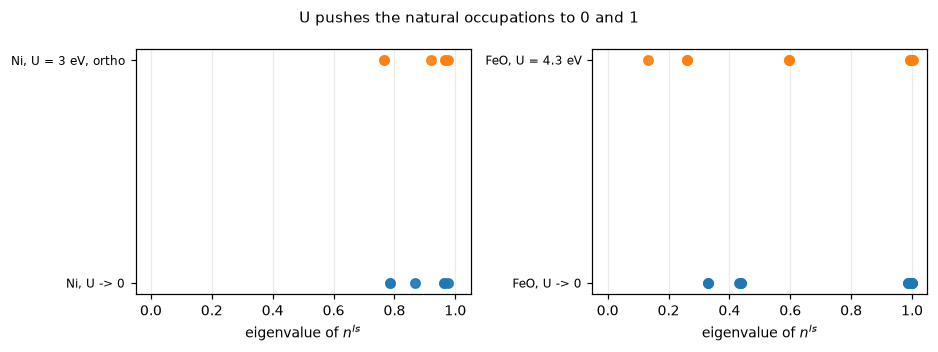

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.2), sharex=True)
for ax, (label, other) in zip(axes, (("Ni, U -> 0", "Ni, U = 3 eV, ortho"),
                                     ("FeO, U -> 0", "FeO, U = 4.3 eV"))):
    for offset, key in enumerate((label, other)):
        result = runs[key][0]
        values = np.concatenate([np.linalg.eigvalsh(np.asarray(result.ns)[s, slot])
                                 for s in range(result.ns.shape[0])
                                 for slot in range(result.ns.shape[1])])
        ax.plot(values, np.full_like(values, offset), "o", ms=6, alpha=0.7,
                color="C%d" % offset)
    ax.set_yticks([0, 1]); ax.set_yticklabels([label, other], fontsize=8)
    ax.set_xlim(-0.05, 1.05); ax.grid(alpha=0.25, axis="x")
    ax.set_xlabel(r"eigenvalue of $n^{Is}$")
fig.suptitle("U pushes the natural occupations to 0 and 1", fontsize=10)
fig.tight_layout()

for label in runs:
    traces = runs[label][0].hubbard_occupations
    print("  %-22s Tr[ns] up/down  %s"
          % (label, "   ".join("atom %d: %.4f / %.4f" % (atom + 1, t[0], t[1])
                               for atom, t in traces.items())))

---
**The detail:** `PLAN.md` §3 P20 — the two offsets a Hubbard manifold needs (`offsetU`
into the Hubbard orbitals, `oatwfc` into *all* the atomic ones), `starting_ns_eigenvalue`
for steering the SCF to a second solution, `force_hub` as `jax.grad` through projectors
that move with the atoms, and what is refused by name (the full Liechtenstein
formulation, the intersite `V`, `ns_nc`).
**The tests:** `tests/regression/test_ldau.py`, `tests/unit/test_hubbard.py`.